# Tox21 EDA: Exploratory Data Analysis 


## 1. Loading the Dataset 


In [3]:
import deepchem as dc
import rdkit
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("DeepChem version:", dc.__version__)
print("RDKit imported OK")
print("All libraries loaded successfully!")

DeepChem version: 2.8.0
RDKit imported OK
All libraries loaded successfully!


In [4]:
# Load the Tox21 dataset
tasks, datasets, transformers = dc.molnet.load_tox21()
train, valid, test = datasets

print("Tasks (the 12 assays):")
for i, task in enumerate(tasks):
    print(f"  {i+1}. {task}")

print(f"\nTraining compounds: {len(train)}")
print(f"Validation compounds: {len(valid)}")
print(f"Test compounds: {len(test)}")

[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerator
[15:28:41] DEPRECATION WARNING: please use MorganGenerat

Tasks (the 12 assays):
  1. NR-AR
  2. NR-AR-LBD
  3. NR-AhR
  4. NR-Aromatase
  5. NR-ER
  6. NR-ER-LBD
  7. NR-PPAR-gamma
  8. SR-ARE
  9. SR-ATAD5
  10. SR-HSE
  11. SR-MMP
  12. SR-p53

Training compounds: 6258
Validation compounds: 782
Test compounds: 783


We have 12 groups (assays), and 7833 compounds, divided into train (6258), validation (782) and test (783) sets.

In [5]:
import numpy as np

# Convert training labels to a DataFrame
df_train = pd.DataFrame(train.y, columns=tasks)

print("Shape of training labels:", df_train.shape)
print("\nFirst 5 rows:")
df_train.head()

Shape of training labels: (6258, 12)

First 5 rows:


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Class Imbalance

One of the core challenges in the Tox21 dataset is severe class imbalance — the vast majority of compounds are **inactive** against any given assay.
This is biologically expected: a random screening library will contain few compounds that happen to hit any specific target. 
This has an important consequence for modelling: **accuracy is a misleading metric**. A model that simply predicts "inactive" for every compound would
achieve ~97% accuracy on NR-PPAR-gamma while being completely useless. 

In [6]:
# Check class distribution - how many actives vs inactives per assay
print("Class distribution per assay (training set):")
print("-" * 50)

for task in tasks:
    counts = df_train[task].value_counts()
    total = len(df_train[task])
    actives = int(counts.get(1.0, 0))
    inactives = int(counts.get(0.0, 0))
    ratio = inactives / actives if actives > 0 else float('inf')
    print(f"{task:<20} actives: {actives:>4}  inactives: {inactives:>4}  ratio: {ratio:.0f}:1")

Class distribution per assay (training set):
--------------------------------------------------
NR-AR                actives:  250  inactives: 6008  ratio: 24:1
NR-AR-LBD            actives:  193  inactives: 6065  ratio: 31:1
NR-AhR               actives:  589  inactives: 5669  ratio: 10:1
NR-Aromatase         actives:  208  inactives: 6050  ratio: 29:1
NR-ER                actives:  646  inactives: 5612  ratio: 9:1
NR-ER-LBD            actives:  299  inactives: 5959  ratio: 20:1
NR-PPAR-gamma        actives:  132  inactives: 6126  ratio: 46:1
SR-ARE               actives:  718  inactives: 5540  ratio: 8:1
SR-ATAD5             actives:  196  inactives: 6062  ratio: 31:1
SR-HSE               actives:  281  inactives: 5977  ratio: 21:1
SR-MMP               actives:  711  inactives: 5547  ratio: 8:1
SR-p53               actives:  276  inactives: 5982  ratio: 22:1


### Visualising the Imbalance

The chart below makes the imbalance immediately clear. Note that the y-axis scale means the active bars are barely visible — this is the whole problem we need to account for in our modelling choices.

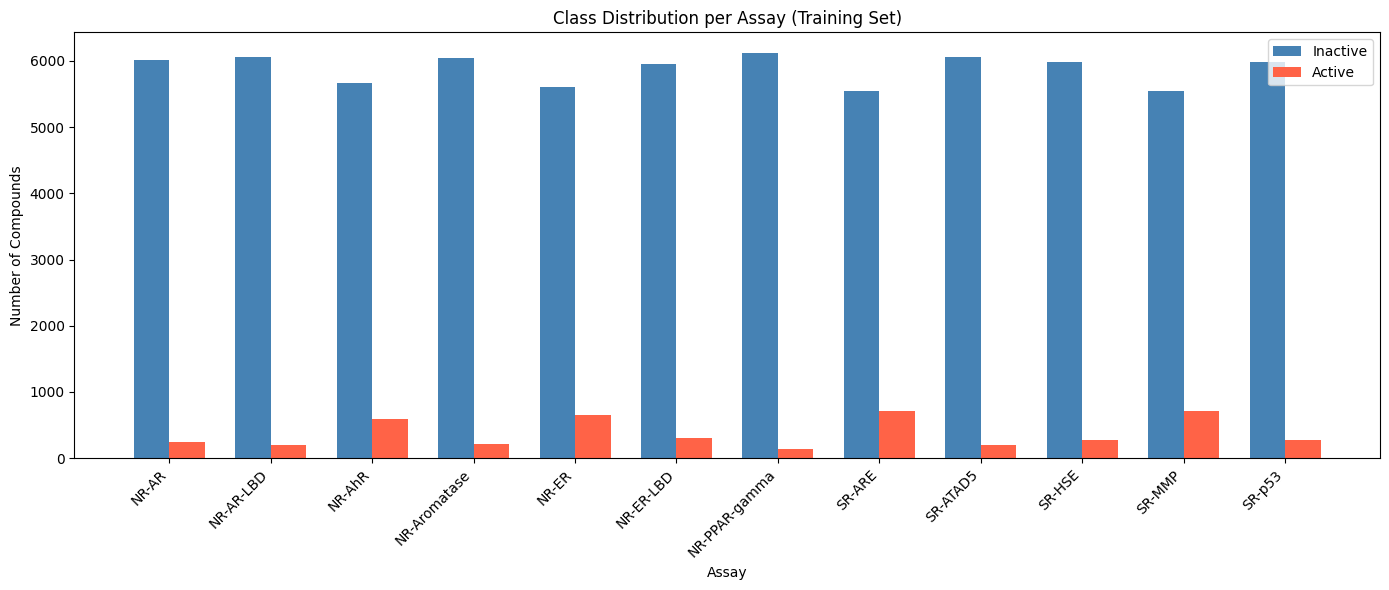

Plot saved!


In [8]:
# Visualise class imbalance
actives_count = [int(df_train[task].value_counts().get(1.0, 0)) for task in tasks]
inactives_count = [int(df_train[task].value_counts().get(0.0, 0)) for task in tasks]

x = np.arange(len(tasks))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, inactives_count, width, label='Inactive', color='steelblue')
bars2 = ax.bar(x + width/2, actives_count, width, label='Active', color='tomato')

ax.set_xlabel('Assay')
ax.set_ylabel('Number of Compounds')
ax.set_title('Class Distribution per Assay (Training Set)')
ax.set_xticks(x)
ax.set_xticklabels(tasks, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150)
plt.show()

print("Plot saved!")

The chart confirms mild to moderate class imbalance across all 12 assays. The active compounds (orange) are barely visible at this scale. NR-PPAR-gamma has the worst imbalance at 46:1, while SR-ARE and SR-MMP are relatively more balanced at 8:1.

This rules out accuracy as a useful metric. We will use **ROC-AUC** throughout this project, which measures the model's ability to **rank** active compounds above inactive ones regardless of threshold.

## 3. Molecular Structure Exploration

Each compound is represented as a **SMILES string** — a text encoding of molecular structure. We can use RDKit to visualise actual molecules from the dataset and examine basic structural properties.

In [9]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors
from rdkit.Chem import rdMolDescriptors

# Get SMILES strings from training set
smiles_list = train.ids

print(f"Total compounds: {len(smiles_list)}")
print(f"\nExample SMILES strings:")
for smi in smiles_list[:5]:
    print(f"  {smi}")

Total compounds: 6258

Example SMILES strings:
  CC(O)(P(=O)(O)O)P(=O)(O)O
  CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C
  OC[C@H](O)[C@@H](O)[C@H](O)CO
  CCCCCCCC(=O)[O-].CCCCCCCC(=O)[O-].[Zn+2]
  CC(C)COC(=O)C(C)C


### Visualising Molecules

We can render the actual 2D molecular structures from their SMILES strings using RDKit. This gives us a sense of the structural diversity in the dataset.

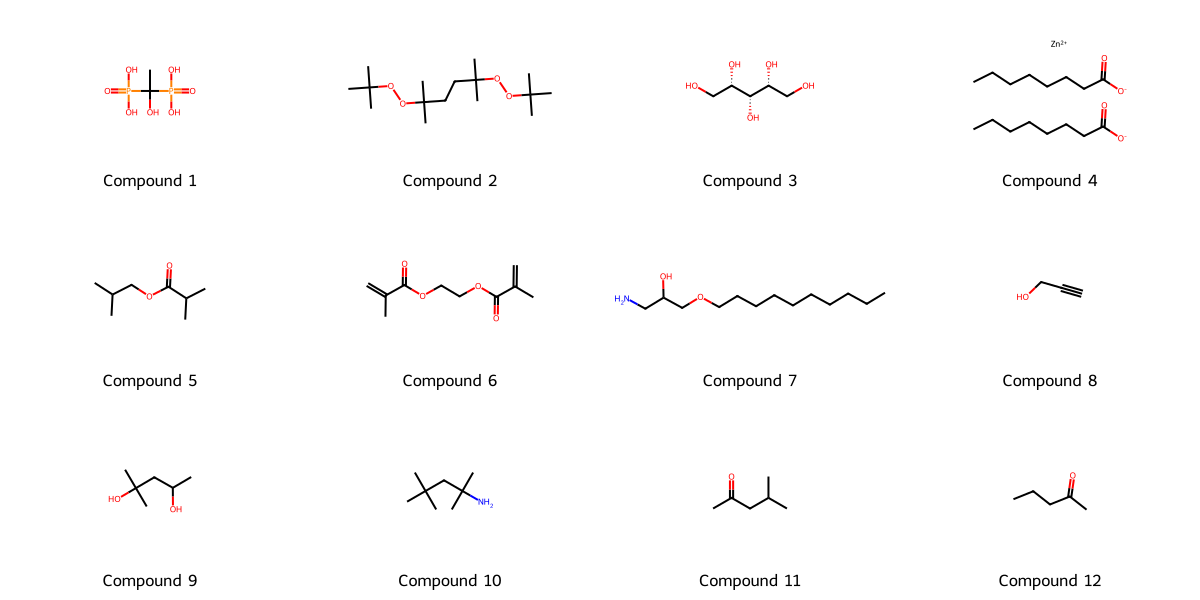

In [13]:
# Draw a grid of molecules
mols = []
for smi in smiles_list[:12]:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mols.append(mol)

img = Draw.MolsToGridImage(
    mols[:12],
    molsPerRow=4,
    subImgSize=(300, 200),
    legends=[f"Compound {i+1}" for i in range(12)],
    returnPNG=False
)

img.save('molecules_grid.png')
img

The first 12 compounds illustrate that the dataset spans a broad range of organic functional groups, including alcohols, ethers, esters, amines, alkynes, ketones, carboxylate salts, with several multifunctional species represented. This variation leads to significant differences in structure, polarity, and reactivity even among relatively small molecules, making the diversity both advantageous for general applicability and challenging for representation, thereby motivating an approach that begins with **Morgan fingerprints** to capture local chemical environments and progresses to **graph neural networks** for direct learning of structural features.


## 4. Physicochemical Properties

Before modelling, it is useful to understand the physicochemical property space of the dataset — particularly molecular weight and lipophilicity (LogP), which strongly influence biological activity.

[20:00:43] WARNING: not removing hydrogen atom without neighbors


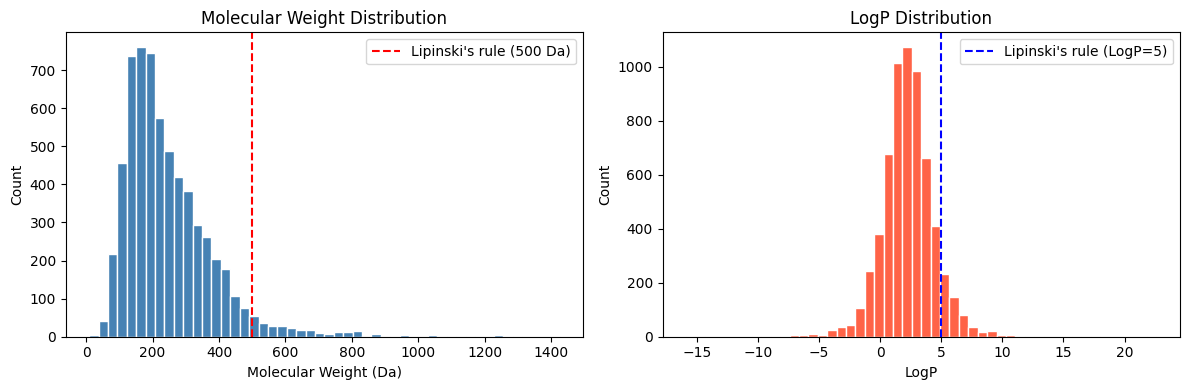

In [14]:
# Calculate basic molecular descriptors
mw_list = []
logp_list = []

for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mw_list.append(Descriptors.MolWt(mol))
        logp_list.append(Descriptors.MolLogP(mol))

df_props = pd.DataFrame({'MolecularWeight': mw_list, 'LogP': logp_list})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_props['MolecularWeight'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Molecular Weight (Da)')
axes[0].set_ylabel('Count')
axes[0].set_title('Molecular Weight Distribution')
axes[0].axvline(500, color='red', linestyle='--', label="Lipinski's rule (500 Da)")
axes[0].legend()

axes[1].hist(df_props['LogP'], bins=50, color='tomato', edgecolor='white')
axes[1].set_xlabel('LogP')
axes[1].set_ylabel('Count')
axes[1].set_title('LogP Distribution')
axes[1].axvline(5, color='blue', linestyle='--', label="Lipinski's rule (LogP=5)")
axes[1].legend()

plt.tight_layout()
plt.savefig('physicochemical_properties.png', dpi=150)
plt.show()

In [ ]:
### Observations

**Molecular Weight:**
- The majority of compounds fall below Lipinski's 500 Da rule, consistent with a drug-like screening library
- The long tail above 500 Da suggests some larger molecules (peptides, polymers, or complex natural products) are included
- The small peak near 0 Da may indicate some problematic entries worth investigating

**LogP (lipophilicity):**
- The distribution is roughly centred around LogP 2-3, consistent with drug-like molecules
- However the extreme outliers (LogP < -10 or > 15) are suspicious and likely represent ionic compounds or salts where the 
  calculated LogP is unreliable — the zinc salt we saw earlier is a good example
- The bulk of compounds fall within Lipinski's LogP ≤ 5 rule

These outliers are a reminder that **calculated descriptors can be unreliable for non-organic compounds** — a known limitation of RDKit's descriptor calculations for metal-containing species.